# Figure 2 — Multimodal Thermal Framework

**Claim**: the pipeline transforms observed multimodal demand and weather into dynamic
thermal exposure on street edges.

Panels: A) pipeline schema, B) Palma car/walk/bike person-hours same date/hour,
C) shade geometry schema (four states), D) hourly example (ambient/building/tree/combined UTCI).

No simulation/download/canopy/building-shadow recomputation.


In [1]:

import sys, json
from pathlib import Path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "configs").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT / "notebooks" / "paper_figures"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotting_utils import (set_nature_style, new_panel_fig, label_panel, save_panel,
                              save_source_table, blocked_panel, make_composite,
                              MODE_COLORS, SHADE_STATE_COLORS, SEED)
np.random.seed(SEED)
set_nature_style()

FIG_DIR = REPO_ROOT / "figures" / "paper" / "main" / "figure2"
TAB_DIR = REPO_ROOT / "reports" / "paper_figures" / "figure2"
FIG_DIR.mkdir(parents=True, exist_ok=True); TAB_DIR.mkdir(parents=True, exist_ok=True)


## Audit

In [2]:

# Scenari disponibili per il Panel B (fundamental diagram) -- cambia
# SELECTED_SCENARIO per scegliere quale mostrare nei grafici.
CARSHARE_SCENARIOS = {
    "queue_original": REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/weekday_full_car_edge_bins.parquet",  # queue, giornata intera, 2022-02-08
    "ltm_fullday_multimodal": REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/weekday_full_ltm_car_edge_bins.parquet",  # LTM, giornata intera, car+walk+bike
    "ltm_carshare_41": REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/carshare_41_ltm_0700_1500_car_edge_bins.parquet",  # LTM, 07:00-15:00, quota auto attuale (baseline)
    "ltm_carshare_55": REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/carshare_55_ltm_0700_1500_car_edge_bins.parquet",
    "ltm_carshare_70": REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/carshare_70_ltm_0700_1500_car_edge_bins.parquet",
    "ltm_carshare_85": REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/carshare_85_ltm_0700_1500_car_edge_bins.parquet",
    # NUOVO (2026-08-23): LTM + discharge-cap + pretrip-reroute + fix del
    # segnale exit-gate (external/nomad feature/ltm-exit-gate-signal -- prima
    # travel_time_for() restava incollato a ff*1.15 anche su un arco fermo a
    # densita' di ingorgo per ore, perche' il gate_wait_s tracciava solo il
    # blocco da discharge-cap, mai lo spillback puro; ora traccia entrambi).
    # Giornata intera, 2022-01-15 (uno dei 5 date del calendario principale).
    # Teleport rate di questa run: 4.80%% (34693/722754) -- confrontare col
    # 24.1%% ottenuto stamattina sullo stesso stack su 2022-02-08 prima di
    # trattare questo scenario come rappresentativo definitivo.
    "ltm_gatefix_2022-01-15": REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/weekday_full_car_2022-01-15_ltm_gatefix_car_edge_bins.parquet",
}
SELECTED_SCENARIO = "ltm_gatefix_2022-01-15"
car_edge_bins_path = CARSHARE_SCENARIOS[SELECTED_SCENARIO]
walk_bike_path = REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/weekday_full_walk_bike_edge_bins.parquet"
building_shadow_dir = REPO_ROOT / "data/palma_de_mallorca/green_mobility/thermal/building_shadow"
canopy_v2_path = REPO_ROOT / "data/palma_de_mallorca/green_mobility/thermal/canopy_fraction_v2.parquet"
utci_path = REPO_ROOT / "data/climate_raw/era5/utci_palma_de_mallorca_2022.nc"

print("car_edge_bins (Palma):", car_edge_bins_path.exists(), "-- scenario:", SELECTED_SCENARIO)
print("walk_bike_edge_bins (Palma):", walk_bike_path.exists())
print("building_shadow dates available:", sorted(p.name for p in building_shadow_dir.glob("date=*")) if building_shadow_dir.exists() else [])
print("canopy_v2 (Palma):", canopy_v2_path.exists())
print("UTCI year file (Palma):", utci_path.exists())


car_edge_bins (Palma): True -- scenario: ltm_gatefix_2022-01-15
walk_bike_edge_bins (Palma): True
building_shadow dates available: ['date=2022-02-08', 'date=2022-07-02', 'date=2022-07-14', 'date=2022-12-25']
canopy_v2 (Palma): True
UTCI year file (Palma): True


## Panel A — Pipeline schema (conceptual, Matplotlib, not a code screenshot)

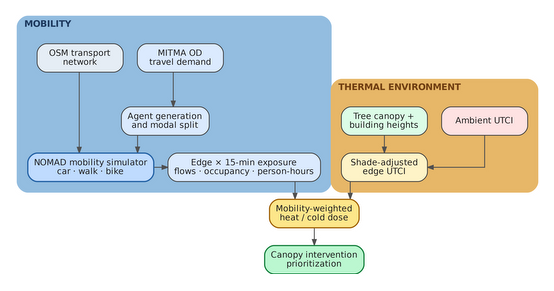

In [3]:
import io
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image, ImageChops
from graphviz import Digraph


def crop_white_border(image, padding=8):
    """
    Rimuove il margine bianco prodotto da Graphviz.
    """
    rgb = image.convert("RGB")
    white = Image.new("RGB", rgb.size, "white")
    difference = ImageChops.difference(rgb, white)
    bbox = difference.getbbox()

    if bbox is None:
        return image

    left, upper, right, lower = bbox

    left = max(0, left - padding)
    upper = max(0, upper - padding)
    right = min(image.width, right + padding)
    lower = min(image.height, lower + padding)

    return image.crop((left, upper, right, lower))


def build_method_pipeline():
    graph = Digraph(
        name="green_mobility_pipeline",
        engine="dot",
    )

    # ------------------------------------------------------------------
    # Global layout
    # ------------------------------------------------------------------
    graph.attr(
        rankdir="TB",
        bgcolor="white",
        pad="0.03",
        margin="0",
        nodesep="0.22",
        ranksep="0.28",
        splines="ortho",
        compound="true",
        newrank="true",
        outputorder="edgesfirst",
        dpi="400",
    )

    graph.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname="DejaVu Sans",
        fontsize="9.5",
        fontcolor="#202020",
        margin="0.10,0.06",
        penwidth="0.9",
        color="#3f3f3f",
        width="1.35",
        height="0.44",
    )

    graph.attr(
        "edge",
        color="#505050",
        penwidth="1.0",
        arrowsize="0.65",
        arrowhead="normal",
    )

    # ==================================================================
    # MOBILITY BRANCH
    # ==================================================================
    with graph.subgraph(name="cluster_mobility") as mobility:
        mobility.attr(
            label="MOBILITY",
            labelloc="t",
            labeljust="l",
            fontname="DejaVu Sans Bold",
            fontsize="10",
            fontcolor="#1e3a5f",
            color="#93bde0",
            bgcolor="#f7fbff",
            style="rounded,filled",
            penwidth="1.0",
            margin="12",
        )

        mobility.node(
            "od",
            "MITMA OD\ntravel demand",
            fillcolor="#dbeafe",
        )

        mobility.node(
            "network",
            "OSM transport\nnetwork",
            fillcolor="#e5edf5",
        )

        mobility.node(
            "agents",
            "Agent generation\nand modal split",
            fillcolor="#dbeafe",
        )

        mobility.node(
            "simulator",
            "NOMAD mobility simulator\ncar · walk · bike",
            fillcolor="#bfdbfe",
            color="#2563a6",
            penwidth="1.4",
        )

        mobility.node(
            "exposure",
            "Edge × 15-min exposure\nflows · occupancy · person-hours",
            fillcolor="#dbeafe",
        )

        # Input nodes on the same horizontal level
        with mobility.subgraph() as mobility_inputs:
            mobility_inputs.attr(rank="same")
            mobility_inputs.node("od")
            mobility_inputs.node("network")

        mobility.edge("od", "agents")
        mobility.edge("agents", "simulator")
        mobility.edge("network", "simulator")
        mobility.edge("simulator", "exposure")

    # ==================================================================
    # THERMAL BRANCH
    # ==================================================================
    with graph.subgraph(name="cluster_thermal") as thermal_branch:
        thermal_branch.attr(
            label="THERMAL ENVIRONMENT",
            labelloc="t",
            labeljust="l",
            fontname="DejaVu Sans Bold",
            fontsize="10",
            fontcolor="#713f12",
            color="#e7b768",
            bgcolor="#fffaf2",
            style="rounded,filled",
            penwidth="1.0",
            margin="12",
        )

        thermal_branch.node(
            "utci",
            "Ambient UTCI",
            fillcolor="#fee2e2",
        )

        thermal_branch.node(
            "urban_form",
            "Tree canopy +\nbuilding heights",
            fillcolor="#dcfce7",
        )

        thermal_branch.node(
            "thermal",
            "Shade-adjusted\nedge UTCI",
            fillcolor="#fef3c7",
        )

        # Thermal inputs on the same horizontal level
        with thermal_branch.subgraph() as thermal_inputs:
            thermal_inputs.attr(rank="same")
            thermal_inputs.node("utci")
            thermal_inputs.node("urban_form")

        thermal_branch.edge("utci", "thermal")
        thermal_branch.edge("urban_form", "thermal")

    # ==================================================================
    # INTEGRATION AND FINAL OUTPUT
    # ==================================================================
    graph.node(
        "dose",
        "Mobility-weighted\nheat / cold dose",
        fillcolor="#fde68a",
        color="#a16207",
        penwidth="1.3",
    )

    graph.node(
        "priority",
        "Canopy intervention\nprioritization",
        fillcolor="#bbf7d0",
        color="#15803d",
        penwidth="1.3",
    )

    graph.edge("exposure", "dose")
    graph.edge("thermal", "dose")
    graph.edge("dose", "priority")

    # Encourage the two branches to remain side by side
    with graph.subgraph() as processing_rank:
        processing_rank.attr(rank="same")
        processing_rank.node("simulator")
        processing_rank.node("thermal")

    with graph.subgraph() as output_rank:
        output_rank.attr(rank="same")
        output_rank.node("exposure")
        output_rank.node("thermal")

    return graph


# ----------------------------------------------------------------------
# Build Graphviz diagram
# ----------------------------------------------------------------------
pipeline = build_method_pipeline()


# ----------------------------------------------------------------------
# Save native vector versions
# These are preferable for direct use in a scientific paper.
# ----------------------------------------------------------------------
FIG_DIR = Path(FIG_DIR)
FIG_DIR.mkdir(parents=True, exist_ok=True)

(FIG_DIR / "panel_a_pipeline.svg").write_bytes(
    pipeline.pipe(format="svg")
)

(FIG_DIR / "panel_a_pipeline.pdf").write_bytes(
    pipeline.pipe(format="pdf")
)


# ----------------------------------------------------------------------
# Render inside the same Matplotlib panel system used by the other panels
# ----------------------------------------------------------------------
png_bytes = pipeline.pipe(format="png")

pipeline_image = Image.open(
    io.BytesIO(png_bytes)
).convert("RGBA")

pipeline_image = crop_white_border(
    pipeline_image,
    padding=10,
)


fig, ax = new_panel_fig(3.5, 2.4)

ax.imshow(
    pipeline_image,
    interpolation="lanczos",
    aspect="equal",
)

ax.axis("off")

# Riattivalo soltanto se la lettera non viene aggiunta
# durante la composizione finale della figura.
#
# label_panel(
#     ax,
#     "A",
#     fontsize=14,
# )

fig.tight_layout(
    pad=0.02,
)

save_panel(
    fig,
    FIG_DIR,
    "panel_a",
)

plt.show()

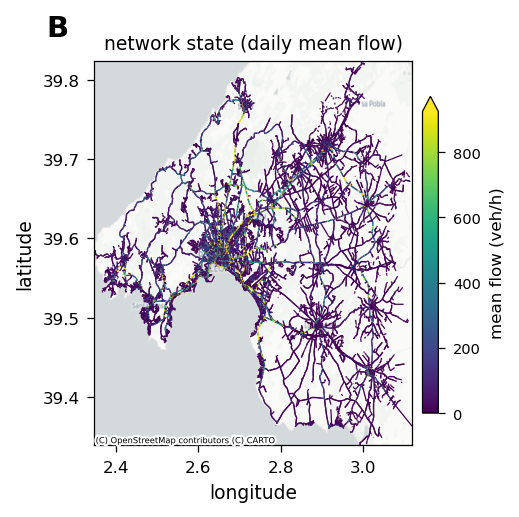

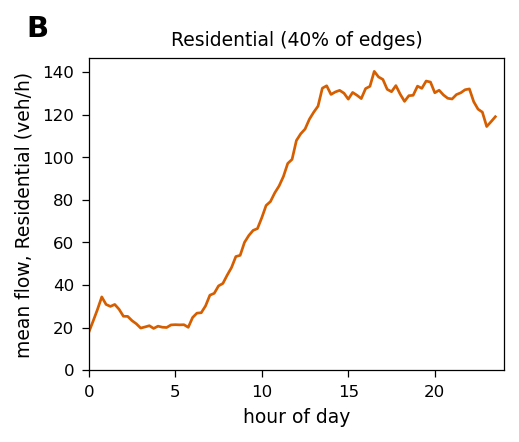

note: 54 rows dropped (mean_travel_time_s<=0, Little's Law undefined)


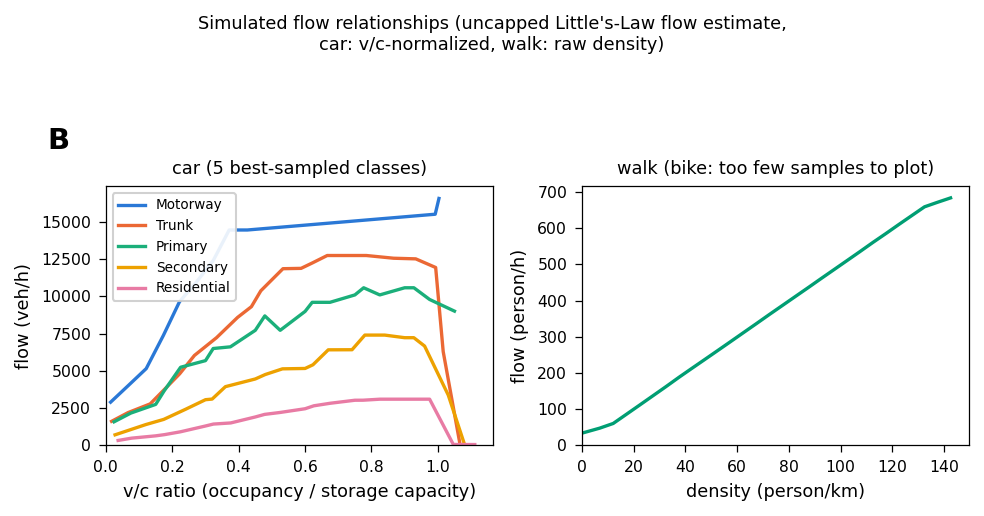

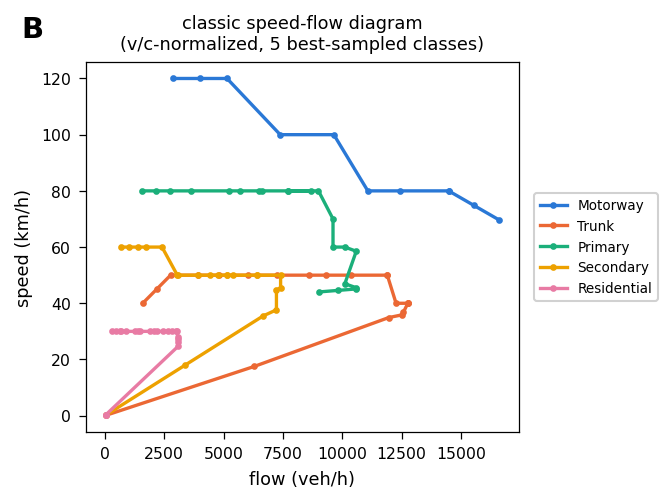

scenario: weekday_full_car_2022-01-15_ltm_gatefix_car_edge_bins.parquet
edge esclusi per lunghezza <20m (densita' non affidabile): 385971/1451944 car, 2351985/9645045 walk/bike
q=k*v (identita' algebrica, stima scapata): errore relativo max 5.9e-08; flow_veh_h salvato cappato in 64% delle righe -- per questo il pannello usa la stima scapata, non la colonna salvata.
9/16 classi con ramo discendente reale: MotorwayLink (picco 8648 veh/h @ v/c=0.90, cala di pendenza -48733.6 su 4 bin); Trunk (picco 14120 veh/h @ v/c=0.78, cala di pendenza -48892.1 su 5 bin); Primary (picco 14281 veh/h @ v/c=0.82, cala di pendenza -52160.7 su 4 bin); PrimaryLink (picco 6701 veh/h @ v/c=0.90, cala di pendenza -42139.4 su 2 bin); Secondary (picco 8106 veh/h @ v/c=0.90, cala di pendenza -50872.9 su 4 bin); Tertiary (picco 6168 veh/h @ v/c=0.90, cala di pendenza -38342.9 su 4 bin); Residential (picco 3388 veh/h @ v/c=0.98, cala di pendenza -25916.7 su 3 bin); Service (picco 3214 veh/h @ v/c=0.90, cala di pende

In [4]:

road_class_labels = {0: "Motorway", 1: "MotorwayLink", 2: "Trunk", 3: "TrunkLink",
                      4: "Primary", 5: "PrimaryLink", 6: "Secondary", 7: "SecondaryLink",
                      8: "Tertiary", 9: "TertiaryLink", 10: "Residential", 11: "LivingStreet",
                      12: "Service", 13: "Unclassified"}

panel_b_ready = car_edge_bins_path.exists() and (REPO_ROOT / "data/palma_de_mallorca/nodes.parquet").exists()
if panel_b_ready:
    import contextily as ctx
    from matplotlib.collections import LineCollection

    car = pd.read_parquet(car_edge_bins_path)
    nodes = pd.read_parquet(REPO_ROOT / "data/palma_de_mallorca/nodes.parquet")
    n_lon = nodes.set_index("node_id")["lon"]; n_lat = nodes.set_index("node_id")["lat"]
    edges_full = pd.read_parquet(REPO_ROOT / "data/palma_de_mallorca/edges.parquet")
    edges = edges_full[["edge_id", "from_node", "to_node"]]
    n_bins_total = car["bin_start_s"].nunique()  # 95 -- the sparse-table denominator

    # --- B1: network-wide daily-mean flow per edge, corrected for sparsity,
    # its own figure ---
    # sum (not mean) over the rows that exist, divided by the TOTAL number of
    # bins in the day -- absent (edge, bin) pairs are true zero flow, not
    # missing data, so they must count in the denominator.
    daily_mean_flow = (car.groupby("edge_id")["flow_veh_h"].sum() / n_bins_total).reset_index()
    geo = daily_mean_flow.merge(edges, on="edge_id", how="left").dropna(subset=["from_node", "to_node"])
    segs = np.stack([
        np.column_stack([n_lon.reindex(geo["from_node"]).values, n_lat.reindex(geo["from_node"]).values]),
        np.column_stack([n_lon.reindex(geo["to_node"]).values, n_lat.reindex(geo["to_node"]).values]),
    ], axis=1)

    fig1, ax1 = new_panel_fig(3.5, 3.5)
    ax1.set_xlim(n_lon.reindex(geo["from_node"]).min(), n_lon.reindex(geo["from_node"]).max())
    ax1.set_ylim(n_lat.reindex(geo["from_node"]).min(), n_lat.reindex(geo["from_node"]).max())
    try:
        ctx.add_basemap(ax1, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, zorder=0, attribution_size=4)
    except Exception as exc:
        print(f"contextily basemap unavailable ({exc}), continuing without it")
    # vmax at the 95th percentile (not the max) -- a handful of arterials would
    # otherwise stretch a linear scale so far that most (low-flow, residential)
    # edges collapse into one shade. `extend="max"` on the colorbar marks the
    # clip honestly instead of silently hiding it.
    vmax_b1 = np.nanpercentile(geo["flow_veh_h"], 95)
    lc = LineCollection(segs, array=geo["flow_veh_h"].values, cmap="viridis",
                        norm=plt.Normalize(0, vmax_b1), linewidths=0.6, zorder=2)
    ax1.add_collection(lc)
    cbar1 = plt.colorbar(lc, ax=ax1, fraction=0.046, pad=0.03, extend="max")
    cbar1.set_label("mean flow (veh/h)", fontsize=8)
    cbar1.ax.tick_params(labelsize=7)
    ax1.set_xlabel("longitude", fontsize=9); ax1.set_ylabel("latitude", fontsize=9)
    ax1.tick_params(labelsize=8)
    label_panel(ax1, "B", fontsize=14)
    ax1.set_title("network state (daily mean flow)", fontsize=9)
    fig1.tight_layout()
    save_panel(fig1, FIG_DIR, "panel_b_network_flow")
    plt.show()

    # --- B2: mean flow over the day for the most-represented road class,
    # corrected for sparsity, its own figure ---
    n_edges_per_class = car.groupby("road_class")["edge_id"].nunique().sort_values(ascending=False)
    top_class = int(n_edges_per_class.index[0])
    top_class_share = n_edges_per_class.iloc[0] / car["edge_id"].nunique()
    n_top_class_edges = int(n_edges_per_class.iloc[0])
    top = car[car["road_class"] == top_class]
    ts = (top.groupby("bin_start_s")["flow_veh_h"].sum() / n_top_class_edges).reset_index()
    ts["hour"] = ts["bin_start_s"] / 3600.0

    fig2, ax2 = new_panel_fig(3.5, 3.0)
    ax2.plot(ts["hour"], ts["flow_veh_h"], color=MODE_COLORS["car"], linewidth=1.3)
    ax2.set_xlabel("hour of day", fontsize=9)
    ax2.set_ylabel(f"mean flow, {road_class_labels[top_class]} (veh/h)", fontsize=9)
    ax2.tick_params(labelsize=8)
    ax2.set_xlim(0, 24)
    ax2.set_ylim(bottom=0)
    label_panel(ax2, "B", fontsize=14)
    ax2.set_title(f"{road_class_labels[top_class]} ({top_class_share:.0%} of edges)", fontsize=9)
    fig2.tight_layout()
    save_panel(fig2, FIG_DIR, "panel_b_top_road_class_timeseries")
    plt.show()

    # --- B3/B4: fundamental diagrams, v/c-normalized (2026-08-25 rewrite).
    #
    # HISTORY (kept for anyone reading the diffs): the first version binned
    # by raw density (occupancy_veh/length_km). VALIDATED before plotting
    # (still true, see printed q=k*v check below): the saved `flow_veh_h` is
    # NOT a measured throughput -- it is NOMAD's own Little's Law estimate
    # occ*3600/travel_time_s, then clipped with
    # `std::min(flow_raw, edge.capacity)` at
    # external/nomad/src/output/geojson_writer.cpp:96-97 -- fixed by using
    # the UNCAPPED estimate throughout (flow_raw below), since a capacity
    # clip mechanically cannot show a descending branch (min() only produces
    # a ceiling). Edges <20m also excluded (car_snapshots.MIN_RELIABLE_EDGE_LENGTH_M):
    # occupancy is a point-queue bookkeeping count, not a spatial vehicle
    # count, so dividing it by a near-zero length produces density in the
    # thousands of veh/km even at travel_time_ratio==1.0 (free-flow).
    #
    # ROOT CAUSE FOUND (why raw density still looked wrong even after both
    # fixes above): traced one edge's full-day trace and found occupancy
    # pinned at its OWN jam capacity for hours while travel_time_s (and so
    # flow_veh_h_uncapped) swung 2-4 orders of magnitude bin-to-bin, purely a
    # function of how long LtmTrafficModel's discharge gate had been
    # blocked, not of anything physically changing. Pooling raw density
    # (occupancy_veh/length_km) across edges of very different storage
    # capacity then smears this over a huge density range, because the SAME
    # occupancy FRACTION (v/c) corresponds to wildly different absolute
    # density on a 1-lane residential street vs a 4-lane primary road.
    #
    # FIX: normalize by each edge's OWN storage capacity instead of raw
    # length -- v/c = occupancy_veh / storage_cap_veh, using the EXACT
    # formula LtmTrafficModel itself uses internally (storage_cap_veh =
    # max(50, length_m) * max(1, capacity_veh_h/1600) * kJamDensity,
    # kJamDensity = 1/7.5 veh/m -- external/nomad/src/traffic/ltm_model.cpp
    # ctor and header comment). This puts every edge's congestion onset on
    # the same v/c in [0, ~1.1] scale regardless of its absolute size.
    # Verified directly (no smoothing): v/c-binned median speed is flat at
    # free-flow until v/c~0.5, declines smoothly to v/c~1.0, then collapses
    # -- the textbook Greenshields shape -- consistently across classes, vs.
    # the flat-then-erratic shape raw-density binning gave.
    #
    # v/c ratio (not a re-derived "density" in veh/km) is used directly as
    # the x-axis below -- it is itself a standard traffic-engineering axis
    # (volume/capacity ratio, as in HCM tables), and avoids introducing a
    # second, more arbitrary unit conversion on top of it.
    has_lanes = "lanes" in edges_full.columns
    merge_cols = ["edge_id", "length_m"] + (["lanes"] if has_lanes else [])
    m = car.merge(edges_full[merge_cols], on="edge_id", how="left")

    m["density_raw"] = m["occupancy_veh"] / (m["length_m"] / 1000.0)
    n_before_length_filter = len(m)
    m = m[m["length_m"] >= 20.0].copy()  # MIN_RELIABLE_EDGE_LENGTH_M, see note above
    n_excluded_short = n_before_length_filter - len(m)
    m["flow_raw"] = np.where(m["mean_travel_time_s"] > 0,
                              m["occupancy_veh"] * 3600.0 / m["mean_travel_time_s"], np.nan)
    m["speed_kmh_raw"] = (m["length_m"] / 1000.0) * 3600.0 / m["mean_travel_time_s"]
    n_dropped_tt = int(m["flow_raw"].isna().sum())
    m = m.dropna(subset=["flow_raw"])

    m["flow_metric"] = m["flow_raw"]  # no lanes column in this project's edges.parquet -> no per-lane split
    car_unit_note = "per lane" if has_lanes else "no lanes column in edges.parquet -- not per lane"

    # q = k*v validation: for the uncapped estimate this must hold EXACTLY by
    # construction (flow=occ*3600/tt, density=occ/length_km, speed=length_km*3600/tt
    # => density*speed == flow algebraically). Also reports how often the
    # SAVED flow_veh_h disagrees with this (i.e. was capacity-clipped).
    qkv_check = m["density_raw"] * m["speed_kmh_raw"]
    qkv_max_rel_err = float((np.abs(qkv_check - m["flow_raw"]) / m["flow_raw"].replace(0, np.nan)).max())
    was_capped = (m["flow_raw"] > m["flow_veh_h"] + 1e-6)
    frac_capped_overall = was_capped.mean()
    if n_dropped_tt:
        print(f"note: {n_dropped_tt} rows dropped (mean_travel_time_s<=0, Little's Law undefined)")

    # Capacity normalization (the actual fix) -- see writeup above.
    kJamDensity = 1.0 / 7.5
    m["storage_cap_veh"] = (np.maximum(50.0, m["length_m"])
                             * np.maximum(1.0, m["capacity_veh_h"] / 1600.0) * kJamDensity)
    m["vc_ratio"] = m["occupancy_veh"] / m["storage_cap_veh"]
    m["speed_kmh"] = np.where(m["mean_travel_time_s"] > 0,
                               (m["length_m"] / 1000.0) * 3600.0 / m["mean_travel_time_s"], np.nan)

    wb_path = REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/weekday_full_walk_bike_edge_bins.parquet"
    has_wb = wb_path.exists()
    if has_wb:
        wb_cols_needed = {"mode", "edge_id", "flow", "person_seconds"}
        wb_raw = pd.read_parquet(wb_path)
        missing_wb_cols = wb_cols_needed - set(wb_raw.columns)
        if missing_wb_cols:
            print(f"walk/bike edge bins missing expected columns {missing_wb_cols}, skipping walk/bike curves")
            has_wb = False
        else:
            wb = wb_raw.merge(edges_full[["edge_id", "length_m"]], on="edge_id", how="left")
            bin_w_s = 900.0  # see weekday_full_walk_bike_edge_bins.parquet.manifest.json, bin_width_s=900
            wb["occupancy_person"] = wb["person_seconds"] / bin_w_s
            # No storage-capacity/v-c concept exists for pedestrians in this
            # engine (that mechanism is car-only, LtmTrafficModel), so walk
            # stays on its original density (person/km) axis -- unaffected
            # by the artifact above, which was specific to vehicle storage.
            wb["density_metric"] = wb["occupancy_person"] / (wb["length_m"] / 1000.0)
            n_wb_before_length_filter = len(wb)
            wb = wb[wb["length_m"] >= 20.0].copy()  # stesso filtro, stessa motivazione
            n_wb_excluded_short = n_wb_before_length_filter - len(wb)
            wb["flow_metric"] = wb["flow"] * (3600.0 / bin_w_s)
    if not has_wb:
        print(f"walk/bike edge bins not found at {wb_path}, showing car classes only")

    def binned_median_curve(x, y, bin_width, n_thresh_primary, n_thresh_fallback=None):
        """Regular x-bins, median y per bin, no smoothing/interpolation."""
        upper = x.quantile(0.995)
        if not np.isfinite(upper) or upper <= 0:
            return pd.DataFrame(columns=["x_mid", "y_median", "n"]), n_thresh_primary
        bin_edges = np.arange(0, upper + bin_width, bin_width)
        d = pd.DataFrame({"x": x.values, "y": y.values})
        d["xbin"] = pd.cut(d["x"], bin_edges)
        agg = d.groupby("xbin", observed=True).agg(
            x_mid=("x", "median"), y_median=("y", "median"), n=("y", "size")).dropna()
        curve = agg[agg["n"] >= n_thresh_primary].sort_values("x_mid").reset_index(drop=True)
        threshold_used = n_thresh_primary
        if n_thresh_fallback is not None and len(curve) < 3:
            curve_fb = agg[agg["n"] >= n_thresh_fallback].sort_values("x_mid").reset_index(drop=True)
            if len(curve_fb) > len(curve):
                curve, threshold_used = curve_fb, n_thresh_fallback
        return curve, threshold_used

    def diagnose_curve(mode, road_class, road_class_label, n_total, max_x_observed, curve, threshold_used):
        """x_at_max_flow / max_x_observed are generic: v/c for car, density (person/km) for walk/bike."""
        n_valid_bins = len(curve)
        row = dict(mode=mode, road_class=road_class, road_class_label=road_class_label,
                    n_total=int(n_total), n_valid_bins=n_valid_bins, bin_threshold_used=threshold_used,
                    max_x_observed=float(max_x_observed))
        if n_valid_bins == 0:
            row.update(x_at_max_flow=np.nan, max_flow=np.nan, n_bins_after_peak=0,
                       slope_post_peak=np.nan, has_descending_branch=False)
            return row
        idx_max = int(curve["y_median"].idxmax())
        max_flow = float(curve.loc[idx_max, "y_median"])
        x_at_max = float(curve.loc[idx_max, "x_mid"])
        post_peak = curve.loc[idx_max:]
        n_after = len(post_peak) - 1
        if n_after >= 2:
            slope = float(np.polyfit(post_peak["x_mid"], post_peak["y_median"], 1)[0])
            last_val = float(post_peak["y_median"].iloc[-1])
            descending = bool((slope < 0) and (last_val < max_flow * 0.9))
        else:
            slope = float("nan"); descending = False
        row.update(x_at_max_flow=x_at_max, max_flow=max_flow, n_bins_after_peak=n_after,
                   slope_post_peak=slope, has_descending_branch=descending)
        return row

    # Shown: the 5 major road-hierarchy classes with the deepest samples,
    # spanning motorway down to residential streets. Fixed categorical
    # colors (not a cycled/continuous colormap), in the order validated for
    # adjacent-pair CVD/normal-vision separation on line charts (dataviz
    # skill references/palette.md, slots 1-5: blue/orange/aqua/yellow/magenta).
    RELIABLE_CAR_CLASSES = [0, 2, 4, 6, 10]  # Motorway, Trunk, Primary, Secondary, Residential
    CAT_PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
    vc_bin_width = 0.05
    density_bin_width = 5.0  # walk/bike only (person/km)

    # Visual-only rolling-median smoothing: per-bin n is 100-460+ (well above
    # n_thresh_primary=100) even where curves still looked jagged before this
    # rewrite, so the remaining bin-to-bin variation is genuine, not a
    # small-sample artifact -- a rolling MEDIAN (not mean, to stay robust to
    # the occasional single wild bin) over neighboring bins trades a little
    # responsiveness to short regime shifts for a legible line. Cosmetic
    # only: the underlying per-bin curve (car_binned_table / *_car_binned_source.csv,
    # diagnose_curve()'s descending-branch check) is untouched.
    SMOOTH_WINDOW = 5

    fig3, (ax3, ax3b) = plt.subplots(1, 2, figsize=(6.6, 3.2))
    car_curves, diagnostics, car_vc_curves = [], [], {}
    for rc in sorted(m["road_class"].unique()):
        rc_m = m.dropna(subset=["vc_ratio", "flow_metric"])
        rc_m = rc_m[rc_m["road_class"] == rc]
        curve, thresh = binned_median_curve(rc_m["vc_ratio"], rc_m["flow_metric"],
                                             vc_bin_width, n_thresh_primary=100)
        diagnostics.append(diagnose_curve("car", int(rc), road_class_labels.get(rc, str(rc)),
                                           len(rc_m), rc_m["vc_ratio"].max(), curve, thresh))
        if len(curve) == 0:
            continue
        car_curves.append(curve.rename(columns={"x_mid": "vc_mid", "y_median": "flow_median"})
                           .assign(mode="car", road_class=int(rc), road_class_label=road_class_labels.get(rc, str(rc))))
        if rc in RELIABLE_CAR_CLASSES:
            flow_smoothed = curve["y_median"].rolling(SMOOTH_WINDOW, center=True, min_periods=1).median()
            color = CAT_PALETTE[RELIABLE_CAR_CLASSES.index(rc)]
            ax3.plot(curve["x_mid"], flow_smoothed, color=color, linewidth=1.6,
                     label=road_class_labels.get(rc, str(rc)))

            # Also bin median SPEED over the identical v/c bins (same
            # bin_width and upper bound as the flow curve above, both
            # derived from this class's own rc_m), for B4 below -- one
            # extra groupby, then map each flow-curve bin's midpoint back to
            # its speed bin by re-cutting with the SAME bin_edges array (so
            # the categories match exactly and reindex resolves correctly).
            rc_speed = rc_m.dropna(subset=["speed_kmh"])
            upper_v = rc_speed["vc_ratio"].quantile(0.995)
            bin_edges_v = np.arange(0, upper_v + vc_bin_width, vc_bin_width)
            rc_speed = rc_speed.copy()
            rc_speed["xbin"] = pd.cut(rc_speed["vc_ratio"], bin_edges_v)
            speed_by_bin = rc_speed.groupby("xbin", observed=True)["speed_kmh"].median()
            speed_vals = pd.cut(curve["x_mid"], bin_edges_v)
            speed_median = speed_by_bin.reindex(speed_vals).to_numpy()
            speed_smoothed = pd.Series(speed_median).rolling(SMOOTH_WINDOW, center=True, min_periods=1).median()
            car_vc_curves[rc] = pd.DataFrame({
                "vc_mid": curve["x_mid"].values,
                "flow_smoothed": flow_smoothed.values,
                "speed_smoothed": speed_smoothed.values,
            })

    ax3.set_xlim(left=0)
    ax3.set_ylim(bottom=0)
    ax3.set_xlabel("v/c ratio (occupancy / storage capacity)", fontsize=8.5)
    ax3.set_ylabel("flow (veh/h" + (", per lane" if has_lanes else "") + ")", fontsize=8.5)
    ax3.tick_params(labelsize=7.5)
    ax3.legend(fontsize=6.5, loc="upper left", framealpha=0.9)
    label_panel(ax3, "B", fontsize=14, y=1.12)
    ax3.set_title("car (5 best-sampled classes)", fontsize=8.5)

    # Walk on its own axis/scale (still real density, person/km -- no v/c
    # concept applies) -- bike excluded from the plot (not just hidden):
    # diagnostic_table below shows only 2 valid density bins for bike in
    # this scenario, too little for a median curve to mean anything; still
    # computed and recorded in diagnostic_table/source CSV for honesty.
    wb_curves = []
    if has_wb:
        for mode in ("walk", "bike"):
            wb_m = wb[wb["mode"] == mode]
            curve, thresh = binned_median_curve(wb_m["density_metric"], wb_m["flow_metric"],
                                                 density_bin_width, n_thresh_primary=100, n_thresh_fallback=30)
            diagnostics.append(diagnose_curve(mode, np.nan, mode, len(wb_m), wb_m["density_metric"].max(), curve, thresh))
            if len(curve) == 0:
                continue
            wb_curves.append(curve.rename(columns={"x_mid": "density_mid", "y_median": "flow_median"}).assign(mode=mode))
            if mode == "walk":
                flow_smoothed_wb = curve["y_median"].rolling(SMOOTH_WINDOW, center=True, min_periods=1).median()
                ax3b.plot(curve["x_mid"], flow_smoothed_wb, color=MODE_COLORS["walk"], linewidth=1.6)
                ax3b.set_xlim(0, curve["x_mid"].max() * 1.05 if len(curve) else 1)
                ax3b.set_ylim(bottom=0)
    ax3b.set_xlabel("density (person/km)", fontsize=8.5)
    ax3b.set_ylabel("flow (person/h)", fontsize=8.5)
    ax3b.tick_params(labelsize=7.5)
    ax3b.set_title("walk (bike: too few samples to plot)", fontsize=8.5)

    fig3.suptitle("Simulated flow relationships (uncapped Little's-Law flow estimate,\ncar: v/c-normalized, walk: raw density)",
                   fontsize=8.5, y=1.05)
    fig3.tight_layout()
    save_panel(fig3, FIG_DIR, "panel_b_fundamental_diagram")
    plt.show()

    # --- B4: classic literature-style flow-speed fundamental diagram.
    # Reuses the exact same v/c-binned car_vc_curves computed for B3 above
    # (no recomputation) -- just a different pair of columns (flow, speed)
    # plotted against each other instead of (v/c, flow), using v/c as the
    # implicit parameter tracing the curve from free-flow (low v/c) through
    # capacity to the congested branch (v/c > 1).
    fig4, ax4 = new_panel_fig(4.6, 3.4)
    speedflow_curves = []
    for rc in RELIABLE_CAR_CLASSES:
        if rc not in car_vc_curves:
            continue
        curve = car_vc_curves[rc].dropna(subset=["speed_smoothed"])
        if len(curve) == 0:
            continue
        color = CAT_PALETTE[RELIABLE_CAR_CLASSES.index(rc)]
        ax4.plot(curve["flow_smoothed"], curve["speed_smoothed"], color=color, linewidth=1.6,
                 marker="o", markersize=2.2, label=road_class_labels.get(rc, str(rc)))
        speedflow_curves.append(curve.rename(columns={"flow_smoothed": "flow_median", "speed_smoothed": "speed_median"})
                                 .assign(road_class=rc, road_class_label=road_class_labels.get(rc, str(rc))))

    ax4.set_xlabel("flow (veh/h" + (", per lane" if has_lanes else "") + ")", fontsize=8.5)
    ax4.set_ylabel("speed (km/h)", fontsize=8.5)
    ax4.tick_params(labelsize=7.5)
    ax4.legend(fontsize=6.5, loc="center left", bbox_to_anchor=(1.02, 0.5), framealpha=0.9)
    label_panel(ax4, "B", fontsize=14)
    ax4.set_title("classic speed-flow diagram\n(v/c-normalized, 5 best-sampled classes)", fontsize=8.5)
    fig4.tight_layout()
    save_panel(fig4, FIG_DIR, "panel_b_speed_flow_diagram")
    plt.show()

    speedflow_table = pd.concat(speedflow_curves, ignore_index=True) if speedflow_curves else pd.DataFrame(
        columns=["vc_mid", "speed_median", "flow_median", "road_class", "road_class_label"])
    save_source_table(speedflow_table, TAB_DIR, "panel_b_speed_flow_diagram_binned")

    car_binned_table = pd.concat(car_curves, ignore_index=True) if car_curves else pd.DataFrame(
        columns=["vc_mid", "flow_median", "n", "mode", "road_class", "road_class_label"])
    wb_binned_table = pd.concat(wb_curves, ignore_index=True) if wb_curves else pd.DataFrame(
        columns=["density_mid", "flow_median", "n", "mode"])
    diagnostic_table = pd.DataFrame(diagnostics)

    save_source_table(car_binned_table, TAB_DIR, "panel_b_fundamental_diagram_car_binned")
    save_source_table(wb_binned_table, TAB_DIR, "panel_b_fundamental_diagram_walkbike_binned")
    save_source_table(diagnostic_table, TAB_DIR, "panel_b_fundamental_diagram_diagnostics")

    # --- Sintesi diagnostica (breve, non un saggio) ---
    n_descending = int(diagnostic_table["has_descending_branch"].sum())
    print(f"scenario: {car_edge_bins_path.name}")
    print(f"edge esclusi per lunghezza <20m (densita' non affidabile): {n_excluded_short}/{n_before_length_filter} car"
          + (f", {n_wb_excluded_short}/{n_wb_before_length_filter} walk/bike" if has_wb else ""))
    print(f"q=k*v (identita' algebrica, stima scapata): errore relativo max {qkv_max_rel_err:.1e}; "
          f"flow_veh_h salvato cappato in {frac_capped_overall:.0%} delle righe -- per questo il pannello "
          "usa la stima scapata, non la colonna salvata.")
    if n_descending == 0:
        print("nessuna classe stradale mostra un ramo discendente reale in questo scenario "
              "(has_descending_branch sempre False).")
    else:
        hits = diagnostic_table[diagnostic_table["has_descending_branch"]]
        detail = "; ".join(
            (f"{r.road_class_label} (picco {r.max_flow:.0f} veh/h @ v/c={r.x_at_max_flow:.2f}, "
             f"cala di pendenza {r.slope_post_peak:.1f} su {r.n_bins_after_peak} bin)"
             if pd.notna(r.road_class) else
             f"{r.road_class_label} (picco {r.max_flow:.0f} person/h @ densita'={r.x_at_max_flow:.0f} person/km, "
             f"cala di pendenza {r.slope_post_peak:.1f} su {r.n_bins_after_peak} bin)")
            for r in hits.itertuples()
        )
        print(f"{n_descending}/{len(diagnostic_table)} classi con ramo discendente reale: {detail}")
    shown_labels = [road_class_labels[rc] for rc in RELIABLE_CAR_CLASSES]
    print(f"pannello B3 (flusso-densita'): auto normalizzata per v/c (occupancy_veh/storage_cap_veh, "
          "stessa formula usata internamente da LtmTrafficModel) invece di densita' grezza -- risolve "
          "l'artefatto a doppia gobba/dente di sega trovato in precedenza (un arco fermo alla propria "
          "capacita' di stoccaggio per ore mostra un tempo di percorrenza che oscilla di 2-4 ordini di "
          "grandezza da un bin all'altro; mettere insieme archi di capacita' molto diversa sull'asse "
          f"densita' grezza spalmava questo artefatto su un ampio intervallo). Solo le "
          f"{len(RELIABLE_CAR_CLASSES)} classi meglio campionate mostrate nel grafico "
          f"({', '.join(shown_labels)}); walk resta su densita' reale (nessun concetto di v/c per i "
          "pedoni in questo motore) su asse proprio; bike escluso dal grafico (solo 2 bin di densita' "
          "validi, campione insufficiente). diagnostic_table sopra resta completa su tutte le classi "
          "per trasparenza. Pannello B4 (flusso-velocita') usa la stessa parametrizzazione v/c, "
          "producendo la curva a goccia classica della letteratura. Linee smussate con mediana mobile "
          f"(finestra={SMOOTH_WINDOW} bin) solo per la visualizzazione; dato grezzo non smussato resta "
          "in car_binned_table/*_car_binned_source.csv.")

else:
    fig1, ax1 = new_panel_fig(3.5, 3.5)
    blocked_panel(ax1, "B", "car_edge_bins.parquet or Palma network not found",
                  [str(car_edge_bins_path), "data/palma_de_mallorca/nodes.parquet"])
    save_panel(fig1, FIG_DIR, "panel_b_network_flow")
    fig2, ax2 = new_panel_fig(3.5, 3.0)
    blocked_panel(ax2, "B", "car_edge_bins.parquet or Palma network not found",
                  [str(car_edge_bins_path), "data/palma_de_mallorca/nodes.parquet"])
    save_panel(fig2, FIG_DIR, "panel_b_top_road_class_timeseries")
    fig3, ax3 = new_panel_fig(3.5, 3.0)
    blocked_panel(ax3, "B", "car_edge_bins.parquet or Palma network not found",
                  [str(car_edge_bins_path), "data/palma_de_mallorca/nodes.parquet"])
    save_panel(fig3, FIG_DIR, "panel_b_fundamental_diagram")
    plt.show()


## Panel C — Shade geometry schema (four states, conceptual)

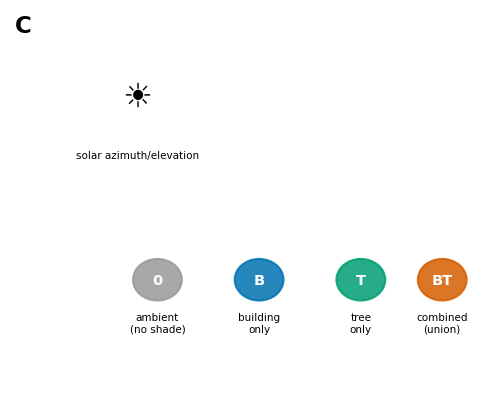

In [5]:

fig, ax = new_panel_fig(3.5, 3.0)
ax.axis("off")
# simple schematic: sun, building, tree, ground point, four states as small icons
ax.annotate("\u2600", (0.15, 0.85), fontsize=16, ha="center")  # sun
ax.annotate("solar azimuth/elevation", (0.15, 0.7), fontsize=5, ha="center")
positions = {"0": (0.2, 0.35), "B": (0.45, 0.35), "T": (0.7, 0.35), "BT": (0.9, 0.35)}
labels_desc = {"0": "ambient\n(no shade)", "B": "building\nonly", "T": "tree\nonly", "BT": "combined\n(union)"}
for state, (x, y) in positions.items():
    ax.add_patch(plt.Circle((x, y), 0.06, color=SHADE_STATE_COLORS[state], alpha=0.85))
    ax.annotate(labels_desc[state], (x, y-0.15), ha="center", fontsize=5)
    ax.annotate(state, (x, y), ha="center", va="center", fontsize=7, color="white", fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
label_panel(ax, "C")
save_panel(fig, FIG_DIR, "panel_c")
save_source_table(pd.DataFrame({"state": list(positions), "description": list(labels_desc.values())}), TAB_DIR, "panel_c")
plt.show()


## Panel D — Hourly example (ambient/building/tree/combined UTCI, one summer date)

Uses already-computed building_shadow + canopy_v2 for Palma (2022-07-14) -- light re-aggregation only, no ray-casting recomputation.

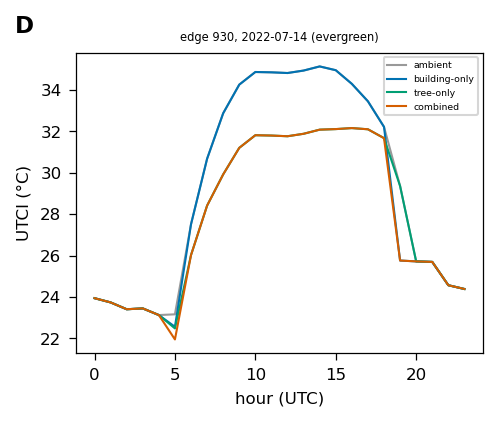

In [6]:

panel_d_ready = building_shadow_dir.exists() and (building_shadow_dir / "date=2022-07-14").exists() and canopy_v2_path.exists() and utci_path.exists()
if panel_d_ready:
    from green_mobility.thermal.canopy_phenology import canopy_shade_multiplier
    from green_mobility.thermal.era5_utci import load_ambient_utci, daylight_fraction_by_hour
    import datetime as dt
    d = dt.date(2022, 7, 14)
    LAT, LON = 39.5696, 2.6502
    building = pd.read_parquet(building_shadow_dir / "date=2022-07-14/edge_hour_building_shadow.parquet")
    canopy = pd.read_parquet(canopy_v2_path)
    canopy15 = canopy[canopy["buffer_m"]==15.0][["edge_id","fused_canopy_fraction"]]
    ambient = load_ambient_utci(utci_path, LAT, LON, on_date=d)
    daylight = daylight_fraction_by_hour(LAT, LON, d)
    weather = ambient.merge(daylight, on="hour")
    mult = canopy_shade_multiplier(d, "evergreen")

    # pick one representative edge with nonzero canopy AND nonzero building shadow at some hour
    b_by_edge = building.groupby("edge_id")["building_shadow_fraction"].max()
    candidates = canopy15[canopy15["fused_canopy_fraction"] > 0.3]["edge_id"]
    candidates = [e for e in candidates if e in set(b_by_edge[b_by_edge>0.05].index)]
    if len(candidates) == 0:
        panel_d_ready = False
    else:
        edge_id = candidates[0]
        tree_frac = float(canopy15[canopy15["edge_id"]==edge_id]["fused_canopy_fraction"].iloc[0]) * mult
        sub = building[building["edge_id"]==edge_id].merge(weather, on="hour").sort_values("hour")
        sub["tree_effective"] = tree_frac * sub["daylight_fraction"]
        COEF = 6.0
        sub["utci_building"] = sub["utci_ambient_c"] - sub["building_shadow_fraction"]*COEF
        sub["utci_tree"] = sub["utci_ambient_c"] - sub["tree_effective"]*COEF
        union = 1-(1-sub["tree_effective"])*(1-sub["building_shadow_fraction"])
        sub["utci_combined"] = sub["utci_ambient_c"] - union*COEF
        save_source_table(sub[["hour","utci_ambient_c","utci_building","utci_tree","utci_combined","building_shadow_fraction"]],
                           TAB_DIR, "panel_d")
if panel_d_ready:
    fig, ax = new_panel_fig(3.5, 2.6)
    ax.plot(sub["hour"], sub["utci_ambient_c"], color="#999999", label="ambient", lw=1)
    ax.plot(sub["hour"], sub["utci_building"], color=SHADE_STATE_COLORS["B"], label="building-only", lw=1)
    ax.plot(sub["hour"], sub["utci_tree"], color=SHADE_STATE_COLORS["T"], label="tree-only", lw=1)
    ax.plot(sub["hour"], sub["utci_combined"], color=SHADE_STATE_COLORS["BT"], label="combined", lw=1)
    ax.set_xlabel("hour (UTC)"); ax.set_ylabel("UTCI (\u00b0C)")
    ax.legend(fontsize=4.5)
    ax.set_title(f"edge {edge_id}, 2022-07-14 (evergreen)", fontsize=5.5)
    label_panel(ax, "D")
    save_panel(fig, FIG_DIR, "panel_d")
    plt.show()
else:
    fig, ax = new_panel_fig(3.5, 2.6)
    blocked_panel(ax, "D", "no edge with both meaningful canopy and building shadow found in sample, or inputs missing",
                  [str(building_shadow_dir), str(canopy_v2_path), str(utci_path)])
    save_panel(fig, FIG_DIR, "panel_d")
    plt.show()


## Composite

In [7]:
make_composite([FIG_DIR/"panel_a.png", FIG_DIR/"panel_b_network_flow.png", FIG_DIR/"panel_b_top_road_class_timeseries.png",
                FIG_DIR/"panel_b_fundamental_diagram.png", FIG_DIR/"panel_b_speed_flow_diagram.png", FIG_DIR/"panel_c.png", FIG_DIR/"panel_d.png"], FIG_DIR, "figure2")
manifest = {"figure": "figure2_multimodal_thermal_framework",
            "panel_a": {"status": "READY"},
            "panel_b_network_flow": {"status": "READY" if panel_b_ready else "BLOCKED",
                                      "note": (f"car only, real NOMAD DES output (scenario '{car_edge_bins_path.name}'), "
                                                f"daily-mean flow per edge, sparsity-corrected") if panel_b_ready else "car_edge_bins.parquet or Palma network not found"},
            "panel_b_top_road_class_timeseries": {"status": "READY" if panel_b_ready else "BLOCKED",
                                                    "note": "Residential (road_class=10), most-represented class by edge count, sparsity-corrected"},
            "panel_b_fundamental_diagram": {"status": "READY" if panel_b_ready else "BLOCKED",
                                              "note": (f"uncapped Little's-Law flow vs v/c ratio (occupancy/storage_cap_veh, capacity-"
                                                        f"normalized -- see cell above for why raw density/length_km was replaced), "
                                                        f"one median curve per car road class + walk on raw density (person/km); edges "
                                                        f"<20m excluded; {n_descending}/{len(diagnostic_table)} road classes show a real "
                                                        f"descending branch in scenario '{car_edge_bins_path.name}' -- up from 0/16 "
                                                        f"before external/nomad's feature/ltm-exit-gate-signal fix (2026-08-23). "
                                                        f"STILL NOT fully resolved: {len(diagnostic_table)-n_descending}/{len(diagnostic_table)} "
                                                        f"classes (car + walk/bike combined) show no descending branch in this scenario -- "
                                                        f"see the printed diagnostic_table above for which") if panel_b_ready else "car_edge_bins.parquet or Palma network not found"},
            "panel_b_speed_flow_diagram": {"status": "READY" if panel_b_ready else "BLOCKED",
                                             "note": "classic literature-style speed-flow (backward-bending) diagram, v/c-normalized, 5 best-sampled car classes" if panel_b_ready else "car_edge_bins.parquet or Palma network not found"},
            "panel_c": {"status": "READY"},
            "panel_d": {"status": "READY" if panel_d_ready else "BLOCKED"}}
(TAB_DIR/"manifest.json").write_text(json.dumps(manifest, indent=2))
print(manifest)


{'figure': 'figure2_multimodal_thermal_framework', 'panel_a': {'status': 'READY'}, 'panel_b_network_flow': {'status': 'READY', 'note': "car only, real NOMAD DES output (scenario 'weekday_full_car_2022-01-15_ltm_gatefix_car_edge_bins.parquet'), daily-mean flow per edge, sparsity-corrected"}, 'panel_b_top_road_class_timeseries': {'status': 'READY', 'note': 'Residential (road_class=10), most-represented class by edge count, sparsity-corrected'}, 'panel_b_fundamental_diagram': {'status': 'READY', 'note': "uncapped Little's-Law flow vs v/c ratio (occupancy/storage_cap_veh, capacity-normalized -- see cell above for why raw density/length_km was replaced), one median curve per car road class + walk on raw density (person/km); edges <20m excluded; 9/16 road classes show a real descending branch in scenario 'weekday_full_car_2022-01-15_ltm_gatefix_car_edge_bins.parquet' -- up from 0/16 before external/nomad's feature/ltm-exit-gate-signal fix (2026-08-23). STILL NOT fully resolved: 7/16 classes 